<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/main/MOD-1/notebooks/04_age_prediction_eda_classification_holdout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Age Prediction: data preparation, Exploratory Data Analysis (EDA), and classification with hold-out & nested hold-out

## Data Preparation and Exploratory Data Analysis (EDA)

Import libraries

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Loading and showing input (features) and output data (desired output)

In [ ]:
df = pd.read_excel('https://raw.githubusercontent.com/sdiciotti/Age-Prediction-Demo/main/NKI2_data.xlsx')
print (type(df))

<class 'pandas.core.frame.DataFrame'>


Print the size of the dataframe

In [ ]:
df.shape

(73, 35)

Print the dataframe

In [ ]:
print(df)

Check the features and output variables name

In [ ]:
features = list(df.columns)
type(features)

list

In [ ]:
print(features)

['Age', 'Sex', 'cortex_CT', 'lh_cortex_CT', 'rh_cortex_CT', 'lh_frontalGM_CT', 'lh_occipitalGM_CT', 'lh_temporalGM_CT', 'lh_parietalGM_CT', 'rh_frontalGM_CT', 'rh_occipitalGM_CT', 'rh_temporalGM_CT', 'rh_parietalGM_CT', 'cortex_pial_lgi', 'lh_cortex_pial_lgi', 'rh_cortex_pial_lgi', 'lh_frontal_pial_lgi', 'lh_occipital_pial_lgi', 'lh_temporal_pial_lgi', 'lh_parietal_pial_lgi', 'rh_frontal_pial_lgi', 'rh_occipital_pial_lgi', 'rh_temporal_pial_lgi', 'rh_parietal_pial_lgi', 'cerebralGM_FD', 'lh_cerebralGM_FD', 'lh_frontalGM_FD', 'lh_temporalGM_FD', 'lh_parietalGM_FD', 'lh_occipitalGM_FD', 'rh_cerebralGM_FD', 'rh_frontalGM_FD', 'rh_temporalGM_FD', 'rh_parietalGM_FD', 'rh_occipitalGM_FD']


Plotting some data

Text(0, 0.5, 'cortex CT (mm)')

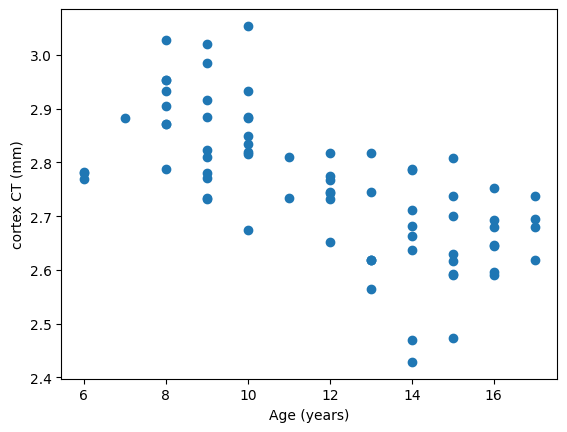

In [ ]:
# Plot true vs predicted values to visualize model performance
plt.scatter(df['Age'],df['cortex_CT'])
plt.xlabel('Age (years)')
plt.ylabel('cortex CT (mm)')

In [ ]:
print("Dataframe shape before NaN removal:", df.shape)

Dataframe shape before NaN removal: (73, 35)


Removing missing data

In [ ]:
df.dropna(axis=0, how='any', inplace=True)
print("Dataframe shape after NaN removal:", df.shape)

Dataframe shape after NaN removal: (72, 35)


Preparing the design matrix X and the desired output y

In [ ]:
X = df.iloc[:,2::]
y = df['Age']
print (type(X))
print (type(y))
print (X.shape)
print (y.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
(72, 33)
(72,)


A quick quality control

In [ ]:
X.head(6)

In [ ]:
print('The whole dataset contains ' + str(X.shape[0]) + ' subjects')
print('The age prediction will be performed using ' + str(X.shape[1]) + ' MRI-derived features')

The whole dataset contains 72 subjects
The age prediction will be performed using 33 MRI-derived features


## Preparing data for a classification task

Define a function to binarize age

In [ ]:
def categorize_age(age): #function implemented to binarize the age
    if age <= 11:
        return 0
    elif age >= 12:
        return 1

Binarizing age to obtain two classes

In [ ]:
df['Age_Category'] = df['Age'].apply(categorize_age) #create a new column in the df using the binarized ages

#df['Age_Category'] = df['Age_Category'].astype(int)

# Count the occurrences of each unique value in the 'Age_Category' column
age_category_counts = df['Age_Category'].value_counts() #counts how many 0 and 1 appears

# Display the counts
print("Number of rows with Age_Category equal to 0:", age_category_counts[0])
print("Number of rows with Age_Category equal to 1:", age_category_counts[1])

Number of rows with Age_Category equal to 0: 32
Number of rows with Age_Category equal to 1: 40


A quick quality control

In [ ]:
df.tail(10)

Extracting "Age_category" and removing the "Age", "Sex" columns from the data

In [ ]:
y = df['Age_Category']
X = df.drop(columns=['Age_Category','Age','Sex']) #start from the original df it cut the listed columns and save it on X

# Convert the 'Age_Category' column to integer type
#df['Age_Category'] = df['Age_Category'].astype(int)

print('The whole dataset contains ' + str(X.shape[0]) + ' subjects')
print('The age prediction will be performed using ' + str(X.shape[1]) + ' MRI-derived features')

The whole dataset contains 72 subjects
The age prediction will be performed using 33 MRI-derived features


A quick quality control

In [ ]:
X.tail(10)

In [ ]:
y.tail(10)

## Classification task

### Logistic regression using a holdout scheme

In [ ]:
from sklearn.linear_model import LogisticRegression #import the logistic regression algorithm
from sklearn.model_selection import train_test_split

# Setting the seed of the random generator
SEED = 42
# Size of the samples in the test set: e.g., 0.1, means that the test set is composed of 10% of the samples of the entire dataset
test_size = 0.1

# Creating the splitter
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=SEED) #divide the dataset in train and test sets

In [ ]:
print (X_train.shape, y_train.shape)
print (X_test.shape, y_test.shape)

(64, 33) (64,)
(8, 33) (8,)


In [ ]:
from sklearn.metrics import roc_auc_score #import the function to compute the AUC

clf_holdout = LogisticRegression(max_iter=1000) #initialize the classificator of LR, specifing max number of iterations
clf_holdout.fit(X_train, y_train) #trains the model computing the coefficients of the line that best divides the two age classes
y_pred_proba_test = clf_holdout.predict_proba(X_test)[:, 1] #instead of directly 0/1 this predict a probability for each class on test set, for all data from the 2 column on
y_pred_proba_train = clf_holdout.predict_proba(X_train)[:, 1] #same but on training set

auc_train = roc_auc_score(y_train, y_pred_proba_train) #compute AUC comparing real labels (train) with predictions (pred_proba_train)
auc_test = roc_auc_score(y_test, y_pred_proba_test) #=

print("Average AUC training set:", auc_train)
print("Average AUC test set:", auc_test)

Average AUC training set: 0.968627450980392
Average AUC test set: 1.0


### Logistic Regression with hyperparameter C (Complexity) using a nested holdout scheme

In [ ]:
#in this block we do a double split, first one we divide the whole dataset in development and test, the second we divide the developmente set in training and validation
from sklearn.model_selection import train_test_split

# Setting the seed of the random generator
SEED = 42

# Size of the samples in the test set: e.g., 0.1, means that the test set is composed of 10% of the samples of the entire dataset
test_size = 0.1

# Size of the samples in the validation set: e.g., 0.1, means that the test set is composed of 10% of the samples of the development set
val_size = 0.1

# Outer hold-out
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=test_size, random_state=SEED)

# Print the size of the development and test sets
print ("The development set size is", "X:", X_dev.shape, "y:", y_dev.shape)
print ("The test set size is", "X:", X_test.shape, "y:", y_test.shape)

# Inner hold-out
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=val_size, random_state=SEED)
# Print the size of the training and validation sets
print ("\nThe development set size is", "X:", X_train.shape, "y:", y_train.shape)
print ("The test set size is", "X:", X_val.shape, "y:", y_val.shape)
print()

The development set size is X: (64, 33) y: (64,)
The test set size is X: (8, 33) y: (8,)

The development set size is X: (57, 33) y: (57,)
The test set size is X: (7, 33) y: (7,)



In [ ]:
AUC = []

C_list = [0.1, 1, 10, 100]

for c in C_list:
    clf = LogisticRegression(max_iter=1000, C=c).fit(X_train, y_train) #initialize the linear classificator imposing max iterations e current hyperparameter C, train the model on training set computing optimal coefficients
    y_pred_proba_val = clf.predict_proba(X_val)[:, 1] #take the prob from the model of the validation set for the positive class (1)
    auc_val = roc_auc_score(y_val, y_pred_proba_val) #compute AUC of the validation set confronting real labels with prob just computed
    print("Average AUC val set:", auc_val)
    AUC.append (auc_val) #add the value
bestC_index = np.argmax(AUC)
bestC = C_list[bestC_index]
print ("\nBest C: ", bestC, "AUC", AUC[bestC_index])

clf = LogisticRegression(max_iter=1000,C=bestC).fit(X_dev, y_dev) #initialize a new LR model with the best C and train it on the whole development set

# Apply the model to the test set and compute the MAE
y_pred_test = clf.predict_proba(X_test)[:, 1] #generate prob predictions for the positive class on test set data
auc_test = roc_auc_score(y_test, y_pred_test) #compute final AUC
print("Average AUC test set:", auc_test)


Average AUC val set: 0.9166666666666667
Average AUC val set: 0.9166666666666667
Average AUC val set: 0.9166666666666667
Average AUC val set: 0.75

Best C:  0.1 AUC 0.9166666666666667
Average AUC test set: 1.0
